# Linear System Solver using Gauss-Jordan Elimination

**Author:** Getabalew Shimelis

This project is a linear system solver from scratch using the
Gauss-Jordan elimination algorithm with row pivoting.

The notebook includes the following cells:

- Custom linear solver implementation
- Correctness testing against NumPy
- Performance benchmarking
- Analysis of results

In [55]:
import numpy as np
import time
import matplotlib.pyplot as plt

## 1. Gauss-Jordan Elimination Solver

The algorithm:

1. Creates an augmented matrix [A | b]
2. Finds a suitable pivot row
3. Swaps rows when necessary
4. Eliminates other rows
5. Extracts the solution vector

In [47]:
def get_first_index_nonzero_from_row(A, column, start_row):
    """
    Find the first non-zero value below the current row.
    
    parameters:
        A: coefficient matrix
        column :column that will check by function
        start_row : starting row for check
    return:
      first non zero index of row 
      if all is non zero it return -1
    
    """

    for i in range(start_row + 1, A.shape[0]):

        if abs(A[i, column]) > 1e-12:
            return i

    return -1



def linear_solver(A, b):
    """
    Solve Ax=b using Gauss-Jordan elimination.

    Parameters:
        A : coefficient matrix
        b : constant vector

    Returns:
        solution vector 
    """

    n = A.shape[0]

    matrix = np.hstack((A, b.reshape(-1,1))).copy()


    for col in range(n):

        # Pivoting
        if abs(matrix[col,col]) < 1e-12:

            switched_row = get_first_index_nonzero_from_row(
                matrix,
                col,
                col
            )

            if switched_row == -1:
                raise ValueError(
                    "Singular matrix"
                )

            matrix[[col, switched_row]] = (
                matrix[[switched_row, col]]
            )


        # Elimination
        for row in range(n):

            if row == col:
                continue


            factor = (
                matrix[row,col] /
                matrix[col,col]
            )

            matrix[row] -= (
                factor *
                matrix[col]
            )


    solution = (
        matrix[:,-1] /
        np.diag(matrix[:,:-1])
    )

    return solution

## 2. Example Test

Compare the custom solver with NumPy.

In [49]:
A = np.array([
    [2.,1.,-1.],
    [-3.,-1.,2.],
    [-2.,1.,2.]
])


b = np.array([
    8.,
    -11.,
    -3.
])


print("Custom Solver:")
print(linear_solver(A,b))


print("\nNumPy:")
print(np.linalg.solve(A,b))

Custom Solver:
[ 2.  3. -1.]

NumPy:
[ 2.  3. -1.]


## 3. Random Correctness and performance Testing 

The solver is tested against `numpy.linalg.solve`
using random nonsingular matrices.

In [59]:
# ==========================================
# Correctness + Performance Benchmark
# ==========================================

sizes = [5, 10, 20, 50, 100]

custom_results = []
numpy_results = []

correct_results = []


for size in sizes:

    if size <= 10:
        tests = 1000
        repeats = 100

    elif size <= 20:
        tests = 300
        repeats = 30

    elif size <= 50:
        tests = 100
        repeats = 10

    else:
        tests = 20
        repeats = 5


    custom_time = 0.0
    numpy_time = 0.0

    correct = 0
    wrong = 0
    failed = 0


    print("\n" + "="*50)
    print(f"Matrix size: {size} x {size}")
    print(f"Tests: {tests}")
    print(f"Repeats per test: {repeats}")


    for _ in range(tests):

        # Generate nonsingular matrix
        while True:

            A = np.random.randint(
                -10,
                11,
                (size, size)
            ).astype(float)

            if abs(np.linalg.det(A)) > 1e-8:
                break


        b = np.random.randint(
            -20,
            21,
            size
        ).astype(float)


        # ==========================
        # Correctness check
        # ==========================

        try:

            my_answer = linear_solver(A, b)

            numpy_answer = np.linalg.solve(A, b)


            if np.allclose(
                my_answer,
                numpy_answer,
                atol=1e-8
            ):
                correct += 1

            else:
                wrong += 1


        except Exception:

            failed += 1



        # ==========================
        # Custom timing
        # ==========================

        start = time.perf_counter()

        for _ in range(repeats):
            linear_solver(A, b)

        custom_time += (
            time.perf_counter() - start
        )


        # ==========================
        # NumPy timing
        # ==========================

        start = time.perf_counter()

        for _ in range(repeats):
            np.linalg.solve(A, b)

        numpy_time += (
            time.perf_counter() - start
        )



    # Average time

    custom_average = (
        custom_time /
        (tests * repeats)
    )

    numpy_average = (
        numpy_time /
        (tests * repeats)
    )


    custom_results.append(custom_average)
    numpy_results.append(numpy_average)


    correct_results.append(correct)



    # Results

    print(f"Correct               : {correct}/{tests}")
    print(f"Wrong                 : {wrong}")
    print(f"Failed                : {failed}")

    print(
        f"Custom average        : "
        f"{custom_average*1e6:.2f} µs"
    )

    print(
        f"NumPy average         : "
        f"{numpy_average*1e6:.2f} µs"
    )

    print(
        f"Speed ratio           : "
        f"{custom_average/numpy_average:.2f}x"
    )


Matrix size: 5 x 5
Tests: 1000
Repeats per test: 100
Correct               : 1000/1000
Wrong                 : 0
Failed                : 0
Custom average        : 60.48 µs
NumPy average         : 9.09 µs
Speed ratio           : 6.66x

Matrix size: 10 x 10
Tests: 1000
Repeats per test: 100
Correct               : 1000/1000
Wrong                 : 0
Failed                : 0
Custom average        : 217.78 µs
NumPy average         : 10.05 µs
Speed ratio           : 21.67x

Matrix size: 20 x 20
Tests: 300
Repeats per test: 30
Correct               : 300/300
Wrong                 : 0
Failed                : 0
Custom average        : 911.48 µs
NumPy average         : 19.99 µs
Speed ratio           : 45.60x

Matrix size: 50 x 50
Tests: 100
Repeats per test: 10
Correct               : 100/100
Wrong                 : 0
Failed                : 0
Custom average        : 5968.68 µs
NumPy average         : 47.85 µs
Speed ratio           : 124.73x

Matrix size: 100 x 100
Tests: 20
Repeats per test:

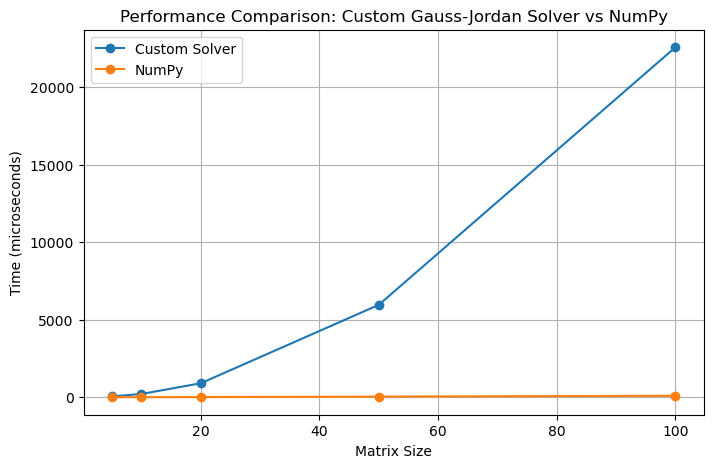

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    sizes,
    np.array(custom_results)*1e6,
    marker="o",
    label="Custom Solver"
)

plt.plot(
    sizes,
    np.array(numpy_results)*1e6,
    marker="o",
    label="NumPy"
)

plt.xlabel("Matrix Size")
plt.ylabel("Time (microseconds)")
plt.title("Performance Comparison: Custom Gauss-Jordan Solver vs NumPy")

plt.legend()
plt.grid(True)

plt.show()

# Conclusion

This project successfully implements a linear system solver from scratch using
the **Gauss-Jordan elimination algorithm with row pivoting**.

## Achievements

- Implemented matrix elimination without relying on external linear algebra solvers
- Added row pivoting to improve numerical stability
- Verified correctness against `numpy.linalg.solve` using thousands of random nonsingular matrices
- Benchmarked performance across different matrix sizes
- Analyzed the trade-off between algorithm understanding and computational efficiency

The custom solver is slower than NumPy because NumPy uses highly optimized
LAPACK routines implemented in compiled languages. These libraries are designed
for high-performance numerical computation and take advantage of advanced
optimizations.

The main goal of this project was not to replace NumPy, but to understand the
mathematical foundations and implementation details behind linear algebra
operations that are widely used in machine learning, data science, and scientific
computing.

## Future Improvements

Possible extensions of this project include:

- Implementing LU decomposition for faster repeated system solving
- Exploring QR decomposition for improved numerical stability
- Using Numba to accelerate Python loops
- Supporting sparse matrices for large-scale systems
- Comparing additional algorithms with different complexity characteristics